## Import Liabraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

## Loading the Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## First 5 rows of the Dataset

In [3]:
print(df.head(5))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
df.shape

(20640, 9)

## Data preprocessing
## Missing values

In [5]:
print('Number of Missing values : \n',df.isnull().sum())

Number of Missing values : 
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## Observation
- There are **No Null Value** in the above dataset.

## Defining features and Target

In [6]:
x = df.drop('MedHouseVal',axis=1)
y = df['MedHouseVal']
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [7]:
print(y)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


## Splitting Data into Training and Testing set

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

## Feature Scaling for Regression

In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Linear Regression Model

In [10]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# prediction
y_pred = model.predict(x_test_scaled)

In [12]:
## Evaluate the model
print('Mean Squared Error :\n',mean_squared_error(y_test,y_pred))
print('R^2:\n',r2_score(y_test,y_pred))

Mean Squared Error :
 0.5558915986952444
R^2:
 0.5757877060324508


In [16]:
# Linear Regression on Polynomial Features
Ir_poly = LinearRegression()
Ir_poly.fit(x_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Prediction
y_pred_train = Ir_poly.predict(x_train_poly)
y_pred_test = Ir_poly.predict(x_test_poly)
print(y_pred_train)
print(y_pred_test)

[1.72932766 3.04531437 2.67234612 ... 2.10456322 2.72185323 2.85804518]
[0.55399741 1.75118566 3.49237927 ... 4.57436358 1.03279128 1.92414302]


In [19]:
# Evaluation
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

In [20]:
print(r2_train)
print(r2_test)
print(rmse_test)

0.6852681982344955
0.6456819729261865
0.6813967448044695


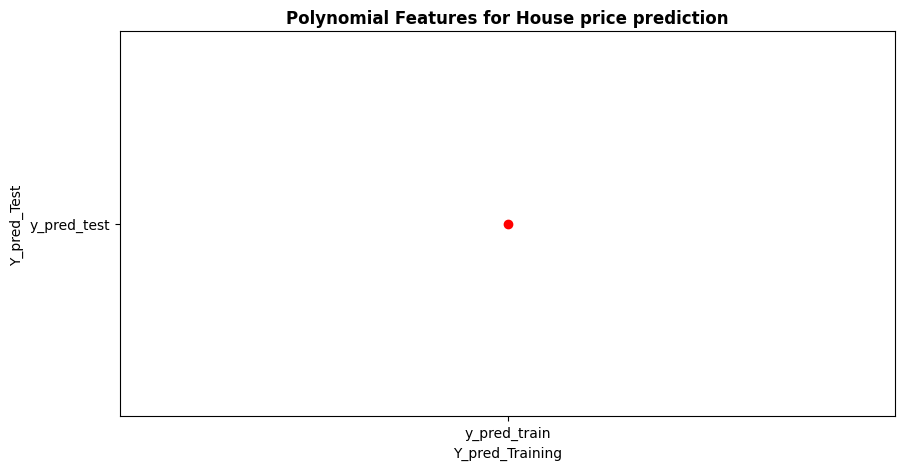

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(x='y_pred_train', y='y_pred_test',alpha=1.0,color='red')
plt.title('Polynomial Features for House price prediction',fontweight='bold')
plt.xlabel('Y_pred_Training')
plt.ylabel('Y_pred_Test')
plt.show()